=== APERCU DU DATASET ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



=== METADATA ===
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



=== INTERPRETATIONS SIMPLES ===
- Âge moyen : 54 ans.
- Cholestérol moyen : 247 mg/dl.
- thalach = fréquence cardiaque maximale à l’effort.
- oldpeak = dépression du segment ST (facteur de risque).
- target = 1 (maladie cardiaque), 0 (pas de maladie).


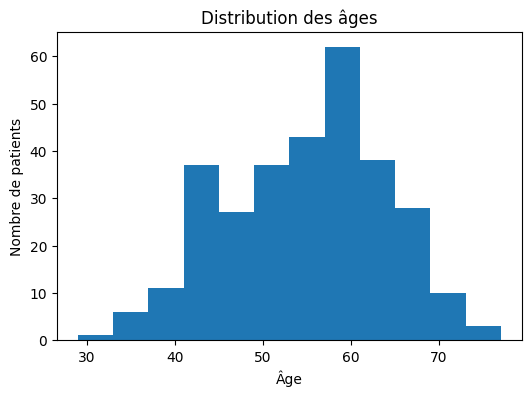

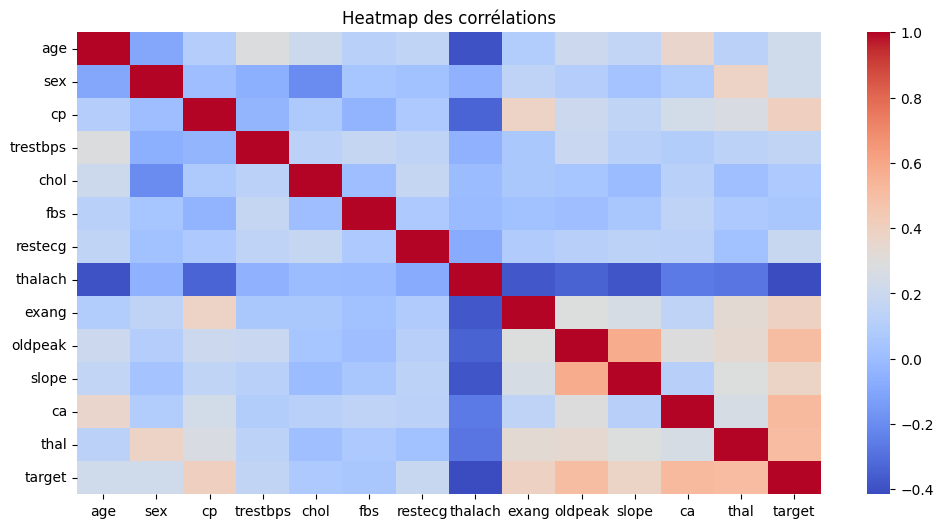

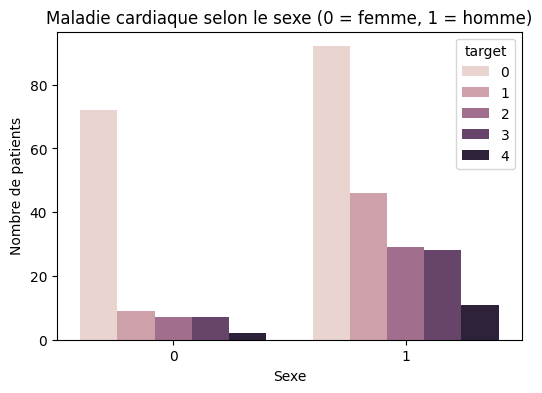


=== RAPPORT AUTOMATIQUE ===

1. Le dataset Heart Disease contient 303 patients avec 14 variables médicales
   afin de prédire la présence d’une maladie cardiaque.

2. Les variables clés sont : âge, douleur thoracique (cp),
   cholestérol, fréquence cardiaque maximale (thalach), oldpeak.

3. Analyse graphique :
   • L'âge se concentre entre 45 et 60 ans.
   • Les hommes présentent plus de cas de maladie cardiaque.
   • Les corrélations montrent l’importance de cp, oldpeak et thalach.

4. Ce rapport constitue une base pour construire un modèle prédictif
   du risque de maladie cardiaque.



In [7]:
# =====================================================
# 1) INSTALLATION & IMPORTS
# =====================================================
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


# =====================================================
# 2) CHARGEMENT DU DATASET
# =====================================================
heart = fetch_ucirepo(id=45)

X = heart.data.features
y = heart.data.targets

df = pd.concat([X, y], axis=1)

# Renommer la colonne cible (num → target)
df = df.rename(columns={"num": "target"})

print("=== APERCU DU DATASET ===")
display(df.head())


# =====================================================
# 3) METADATA & VARIABLES
# =====================================================
print("\n=== METADATA ===")
print(heart.metadata)

print("\n=== VARIABLES ===")
print(heart.variables)


# =====================================================
# 4) STATISTIQUES DESCRIPTIVES + INTERPRETATION
# =====================================================
print("\n=== STATISTIQUES DESCRIPTIVES ===")
display(df.describe())

print("\n=== INTERPRETATIONS SIMPLES ===")
print(f"- Âge moyen : {round(df['age'].mean())} ans.")
print(f"- Cholestérol moyen : {round(df['chol'].mean())} mg/dl.")
print("- thalach = fréquence cardiaque maximale à l’effort.")
print("- oldpeak = dépression du segment ST (facteur de risque).")
print("- target = 1 (maladie cardiaque), 0 (pas de maladie).")


# =====================================================
# 5) GRAPHES
# =====================================================

# --- Graphique 1 : Distribution des âges ---
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=12)
plt.title("Distribution des âges")
plt.xlabel("Âge")
plt.ylabel("Nombre de patients")
plt.show()

# --- Graphique 2 : Heatmap des corrélations ---
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Heatmap des corrélations")
plt.show()

# --- Graphique 3 : Maladie selon le sexe ---
plt.figure(figsize=(6,4))
sns.countplot(x="sex", hue="target", data=df)
plt.title("Maladie cardiaque selon le sexe (0 = femme, 1 = homme)")
plt.xlabel("Sexe")
plt.ylabel("Nombre de patients")
plt.show()


# =====================================================
# 6) MINI-RAPPORT AUTOMATIQUE
# =====================================================
print("\n=== RAPPORT AUTOMATIQUE ===")
print("""
1. Le dataset Heart Disease contient 303 patients avec 14 variables médicales
   afin de prédire la présence d’une maladie cardiaque.

2. Les variables clés sont : âge, douleur thoracique (cp),
   cholestérol, fréquence cardiaque maximale (thalach), oldpeak.

3. Analyse graphique :
   • L'âge se concentre entre 45 et 60 ans.
   • Les hommes présentent plus de cas de maladie cardiaque.
   • Les corrélations montrent l’importance de cp, oldpeak et thalach.

4. Ce rapport constitue une base pour construire un modèle prédictif
   du risque de maladie cardiaque.
""")
